# 📊 InsightML Studio

# Notebook 01 — Data Understanding

---

## Objective

This notebook performs an initial exploration of the dataset before any preprocessing or modeling.

It focuses on:

- Understanding the dataset structure
- Identifying data types
- Detecting missing values
- Finding duplicate records
- Exploring target distribution
- Inspecting numerical and categorical features
- Understanding overall data quality

This notebook forms the foundation of the complete machine learning workflow.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_style("whitegrid")

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "../data/raw/bank_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [3]:
# ==========================================================
# Dataset Shape
# ==========================================================

rows, cols = df.shape

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

print("\n")

display(df.head())

DATASET OVERVIEW
Rows    : 28,382
Columns : 21




,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.00,self_employed,187.00,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.00,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.00,salaried,146.00,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.00,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.00,self_employed,1494.00,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [4]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  

In [5]:
# ==========================================================
# First & Last Records
# ==========================================================

print("First Five Rows")
display(df.head())

print("\nLast Five Rows")
display(df.tail())

First Five Rows


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.00,self_employed,187.00,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.00,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.00,salaried,146.00,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.00,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.00,self_employed,1494.00,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03



Last Five Rows


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
28377,30297,2325,10,Female,0.00,student,1020.00,2,1207,1076.43,1076.43,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22
28378,30298,1537,34,Female,0.00,self_employed,1046.00,2,223,3844.10,4069.21,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17
28379,30299,2376,47,Male,0.00,salaried,1096.00,2,588,65511.97,61017.55,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31
28380,30300,1745,50,Male,3.00,self_employed,1219.00,3,274,1625.55,1625.55,1683.20,1857.42,0.20,0.20,0.20,0.20,1625.55,1625.55,0,NaT
28381,30301,1175,18,Male,0.00,student,1232.00,2,474,2107.05,2821.34,3213.44,4447.45,0.11,7.44,714.40,1094.09,2402.62,3260.58,1,2019-11-02


,Missing Values,Percentage
dependents,2463,8.68
city,803,2.83
gender,525,1.85
occupation,80,0.28
customer_id,0,0.00
vintage,0,0.00
age,0,0.00
customer_nw_category,0,0.00
branch_code,0,0.00
current_balance,0,0.00


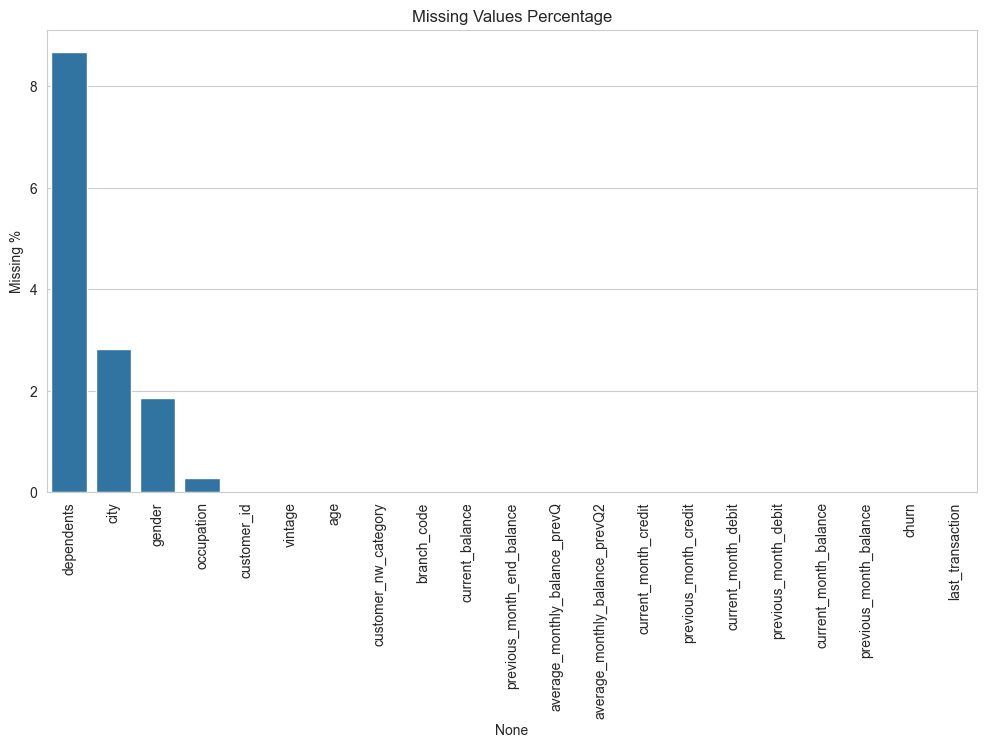

In [6]:
# ==========================================================
# Missing Values Analysis
# ==========================================================

missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": round(df.isnull().mean()*100,2)

})

missing = missing.sort_values(

    by="Missing Values",

    ascending=False

)

display(missing)

plt.figure(figsize=(12,6))

sns.barplot(

    x=missing.index,

    y=missing["Percentage"]

)

plt.xticks(rotation=90)

plt.ylabel("Missing %")

plt.title("Missing Values Percentage")

plt.show()

In [7]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("="*50)

print(f"Duplicate Rows : {duplicates}")

print("="*50)

Duplicate Rows : 0


In [8]:
# ==========================================================
# Unique Values
# ==========================================================

unique = pd.DataFrame({

    "Unique Values": df.nunique()

})

display(unique.sort_values(

    by="Unique Values"

))

,Unique Values
gender,2
churn,2
customer_nw_category,3
occupation,5
dependents,15
age,90
last_transaction,361
vintage,1459
city,1604
branch_code,3185


In [9]:
# ==========================================================
# Numerical Features Summary
# ==========================================================

display(

    df.describe().T

)

,count,mean,std,min,25%,50%,75%,max
customer_id,28382.00,15143.51,8746.45,1.00,7557.25,15150.50,22706.75,30301.00
vintage,28382.00,2091.14,272.68,73.00,1958.00,2154.00,2292.00,2476.00
age,28382.00,48.21,17.81,1.00,36.00,46.00,60.00,90.00
dependents,25919.00,0.35,1.00,0.00,0.00,0.00,0.00,52.00
city,27579.00,796.11,432.87,0.00,409.00,834.00,1096.00,1649.00
customer_nw_category,28382.00,2.23,0.66,1.00,2.00,2.00,3.00,3.00
branch_code,28382.00,925.98,937.80,1.00,176.00,572.00,1440.00,4782.00
current_balance,28382.00,7380.55,42598.71,-5503.96,1784.47,3281.26,6635.82,5905904.03
previous_month_end_balance,28382.00,7495.77,42529.35,-3149.57,1906.00,3379.91,6656.53,5740438.63
average_monthly_balance_prevQ,28382.00,7496.78,41726.22,1428.69,2180.95,3542.86,6666.89,5700289.57


In [10]:
# ==========================================================
# Categorical Features Summary
# ==========================================================

display(

    df.describe(include="object").T

)

,count,unique,top,freq
gender,27857,2,Male,16548
occupation,28302,5,self_employed,17476
last_transaction,28382,361,NaT,3223


In [11]:
# ==========================================================
# Target Column Detection
# ==========================================================

possible_targets = [

    "target",

    "label",

    "class",

    "output",

    "prediction",

    "churn",

    "price",

    "salary"

]

target = None

for col in df.columns:

    if col.lower() in possible_targets:

        target = col

        break

if target is None:

    target = df.columns[-1]

print(f"Detected Target Column : {target}")

Detected Target Column : churn


churn
0    23122
1     5260
Name: count, dtype: int64

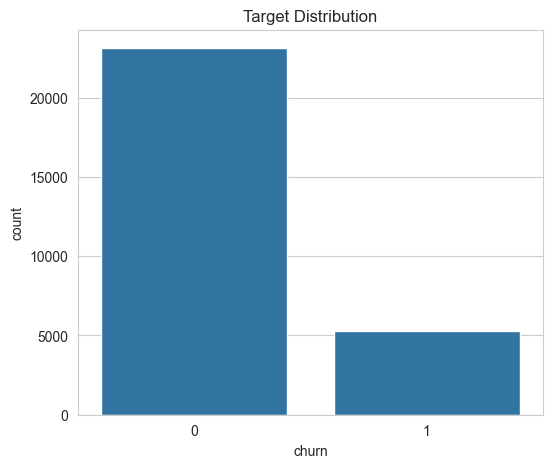

In [12]:
# ==========================================================
# Target Distribution
# ==========================================================

display(

df[target].value_counts()

)

plt.figure(figsize=(6,5))

sns.countplot(

x=df[target]

)

plt.title("Target Distribution")

plt.show()

In [13]:
# ==========================================================
# Dataset Memory Usage
# ==========================================================

memory = df.memory_usage(deep=True).sum()/1024**2

print(f"Memory Usage : {memory:.2f} MB")

Memory Usage : 8.54 MB


# 📌 Key Findings

### Dataset Summary

- Total Rows:
- Total Columns:
- Missing Values:
- Duplicate Records:
- Numerical Features:
- Categorical Features:
- Target Column:

---

## Initial Observations

- Identify columns with significant missing values.
- Inspect high-cardinality categorical features.
- Note any class imbalance in the target variable.
- Plan preprocessing steps (imputation, encoding, scaling).
- Decide whether feature engineering is required.

---

